# Step 6 — Project the 11 ST clusters onto Cedars-Sinai (Ronai_BRCA)

Same pipeline as notebook 04 (Seurat anchor-based transfer + per-patient aggregation),
applied to the Cedars-Sinai cohort. The cohort uses a different tuned parameter
preset — see `TRANSFER_PRESETS$Cedars_Sinai` in
[`../lib/transfer_TCGA_to_external.R`](../lib/transfer_TCGA_to_external.R). The
preset values were lifted from `spatial_clusters/2_Ronai_Seurat_winningc.r`.

**Inputs (committed under `clustering/data/`)**
- `cedars_sinai_query.qs` — Seurat object for the Cedars-Sinai cohort: 210 SpaGCN
  domains across 30 slides. (Reference TCGA Seurat object stays upstream — too large to commit.)
- `tcga_spatiotypes_reference.csv` — TCGA per-patient cluster proportions + SpatioType labels (for the SpatioType projection used to annotate the heatmap).

**Outputs (committed under `clustering/data/`)**
- `cedars_sinai_per_domain.csv` — one row per query domain with the predicted ST cluster.
- `cedars_sinai_cluster_props.csv` — per-patient × per-cluster proportion matrix (30 × 11).

## Setup

In [1]:
import sys, subprocess
sys.path.append("../lib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

from clustering_helpers import (
    SPATIOTYPE_PALETTE, HEATMAP_ROW_ORDER,
    build_spatiotype_centroids, project_spatiotypes,
)

import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

REFERENCE_QS = "/vf/users/Ruppin_ST/scr/new_tras_clusters/tcga_target_seurat_best_genes.qs"
QUERY_QS     = "../data/cedars_sinai_query.qs"

/home/shulmaned/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## What are `target` and `query`?

- **`target` — TCGA reference.** 7,766 domains across 858 TCGA-BRCA slides, with `mapped_clusters` per domain. Same object used in notebook 04.
- **`query` — Cedars-Sinai.** 210 SpaGCN domains across 30 slides. Per-domain Seurat object built upstream from the pseudo-spot expression.

The inspector cell below prints summaries of both via R (commented out by
default; requires R + Seurat + the upstream `.qs` files).

In [2]:
def inspect_qs(qs_path, label):
    res = subprocess.run(
        ["bash", "-c",
         f"source /etc/profile.d/modules.sh 2>/dev/null; "
         f"module load R/4.3.2 2>/dev/null; "
         f"Rscript ../lib/inspect_seurat.R {qs_path} '{label}'"],
        capture_output=True, text=True,
    )
    print("\n".join(l for l in res.stdout.splitlines() if "lscratch" not in l))

# inspect_qs(REFERENCE_QS, "TCGA reference (target)")     # uncomment to run
# inspect_qs(QUERY_QS,    "Cedars-Sinai query")           # uncomment to run

## Stage 1 — Project labels

Same R script as notebook 04, but with the `Cedars_Sinai` preset
(`k.anchor=195, k.score=200, l2.norm=TRUE, k.filter=50, nn.method="rann", k.weight=15`).

The output `cedars_sinai_cluster_props.csv` is shipped pre-computed.

In [3]:
OUT_CSV = "../data/cedars_sinai_cluster_props.csv"

# Uncomment to re-run the projection (needs R + Seurat + access to the reference .qs):
# subprocess.run(["bash", "-c",
#     f"source /etc/profile.d/modules.sh; module load R/4.3.2; "
#     f"Rscript ../lib/transfer_TCGA_to_external.R "
#     f"{REFERENCE_QS} {QUERY_QS} {OUT_CSV} Cedars_Sinai"],
#     check=True)

per_patient = pd.read_csv(OUT_CSV, index_col=0)
print("Cohort:", len(per_patient), "patients,",
      sum(per_patient.values.sum(axis=0) > 0), "of 11 clusters present.")
per_patient.head()

Cohort: 30 patients, 9 of 11 clusters present.


,Cluster_1,Cluster_2,Cluster_3,Cluster_4,Cluster_5,Cluster_6,Cluster_7,Cluster_8,Cluster_9,Cluster_10,Cluster_11
slide_name,,,,,,,,,,,
Ronai_BRCA2_000_DM-9606-4-001.svs,0.030550,0.0,0,0.18775,0.0,0.000000,0.00000,0.268871,0.000000,0.512828,0
Ronai_BRCA2_001_DM-9606-4-002.svs,0.181152,0.0,0,0.00000,0.0,0.000000,0.00000,0.818848,0.000000,0.000000,0
Ronai_BRCA2_002_DM-9606-4-003.svs,0.069296,0.0,0,0.00000,0.0,0.081418,0.00000,0.051927,0.000000,0.797358,0
Ronai_BRCA2_003_DM-9606-4-004.svs,0.000000,0.0,0,0.00000,0.0,0.000000,0.10237,0.000000,0.000000,0.897630,0
Ronai_BRCA2_004_DM-9606-4-005.svs,0.489093,0.0,0,0.00000,0.0,0.000000,0.00000,0.251435,0.163031,0.096441,0


## Stage 2 — Project SpatioTypes (Aitchison centroid)

Same method as notebook 05: nearest TCGA centroid in CLR space.

In [4]:
tcga = pd.read_csv("../data/tcga_spatiotypes_reference.csv", index_col=0)
tcga_cluster_cols = [c for c in tcga.columns if c.startswith("Cluster")]
centroids = build_spatiotype_centroids(
    tcga, spatiotype_col="SpatioType", cluster_cols=tcga_cluster_cols,
    keep=("Immune-Modulated", "Immune-Inactive", "Proliferative"),
)

mb_cols = [c for c in per_patient.columns if c.startswith("Cluster")]
proj = project_spatiotypes(per_patient, centroids, cluster_cols=mb_cols)
proj.to_csv("../data/cedars_sinai_spatiotypes.csv")
proj["SpatioType"].value_counts()

SpatioType
Immune-Inactive     15
Immune-Modulated    11
Proliferative        4
Name: count, dtype: int64

## Stage 3 — Heatmap of cluster proportions (z-score)

Rows = the 11 ST clusters in the paper-frozen order; columns = patients grouped
by their projected SpatioType, Ward-ordered within block. Row-wise z-score
(per cluster across patients), with a 3-stop viridis ramp centred at 2.85 —
matching the paper.

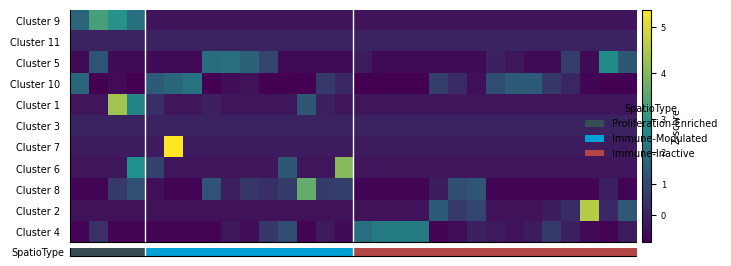

In [5]:
df_h = per_patient.join(proj[["SpatioType"]], how="inner")
df_h = df_h.rename(columns={f"Cluster_{i}": f"Cluster {i}" for i in range(1, 12)})
df_h["SpatioType"] = df_h["SpatioType"].replace({"Proliferative": "Proliferation-Enriched"})

main_st = ["Proliferation-Enriched", "Immune-Modulated", "Immune-Inactive"]

from scipy.cluster.hierarchy import linkage, leaves_list
ordered = []
for st in main_st:
    block = df_h.index[df_h["SpatioType"] == st]
    if len(block) > 1:
        sub_mat = df_h.loc[block, HEATMAP_ROW_ORDER].values
        block = block[leaves_list(linkage(sub_mat, method="ward"))]
    ordered.extend(block)

raw = df_h.loc[ordered, HEATMAP_ROW_ORDER].T.values            # 11 × N
col_st = df_h.loc[ordered, "SpatioType"].values

# Row-wise z-score
mu  = raw.mean(axis=1, keepdims=True)
sig = raw.std(axis=1, keepdims=True); sig[sig == 0] = 1
heat = (raw - mu) / sig

from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
v_lo, v_mid, v_hi = float(heat.min()), 2.85, float(heat.max())
cmap = LinearSegmentedColormap.from_list(
    "viridis3", plt.get_cmap("viridis")(np.linspace(0, 1, 3)), N=256
)
norm = TwoSlopeNorm(vmin=v_lo, vcenter=min(v_mid, v_hi - 1e-6), vmax=v_hi)

boundaries = []
prev = col_st[0]
for i, s in enumerate(col_st):
    if s != prev:
        boundaries.append(i); prev = s

fig = plt.figure(figsize=(7.5, 3.2))
gs = gridspec.GridSpec(2, 2, figure=fig,
                       width_ratios=[60, 1], height_ratios=[30, 1],
                       hspace=0.05, wspace=0.02)
ax_h = fig.add_subplot(gs[0, 0])
im = ax_h.imshow(heat, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest")
for b in boundaries: ax_h.axvline(b - 0.5, color="white", linewidth=1.0)
ax_h.set_yticks(range(len(HEATMAP_ROW_ORDER)))
ax_h.set_yticklabels(HEATMAP_ROW_ORDER, fontsize=7)
ax_h.set_xticks([]); ax_h.tick_params(left=False)

ax_cb = fig.add_subplot(gs[0, 1])
plt.colorbar(im, cax=ax_cb).set_label("Z-score", fontsize=7)
ax_cb.tick_params(labelsize=6)

ax_a = fig.add_subplot(gs[1, 0], sharex=ax_h)
rgb = np.array([list(mcolors.to_rgb(SPATIOTYPE_PALETTE[s])) for s in col_st])[None, :, :]
ax_a.imshow(rgb, aspect="auto", interpolation="nearest")
ax_a.set_xticks([]); ax_a.set_yticks([])
ax_a.set_ylabel("SpatioType", rotation=0, ha="right", va="center", fontsize=7)
for b in boundaries: ax_a.axvline(b - 0.5, color="white", linewidth=1.0)

present_st = [s for s in main_st if s in col_st]
handles = [mpatches.Patch(facecolor=SPATIOTYPE_PALETTE[s], label=s) for s in present_st]
fig.legend(handles=handles, loc="center right", bbox_to_anchor=(1.0, 0.5),
           fontsize=7, frameon=False, title="SpatioType", title_fontsize=7)
plt.show()